## CODIGO PARA VECTORIZACION CON ROBERTUITO


### Arquitectura de RoBERTuito

#### 1. El Estándar Industrial (La Arquitectura "Base")
- RoBERTuito está construido sobre la arquitectura de **RoBERTa** (creada por Facebook/Meta), que a su vez es una mejora de **BERT** (creado por Google).
- Cuando los ingenieros de Google diseñaron BERT, definieron dos tamaños estándar:
  - **Modelo "Base":** Diseñado para correr en hardware normal (tarjetas gráficas estándar). Su tamaño oculto (hidden size) se fijó en **768**.
  - **Modelo "Large":** Diseñado para supercomputadoras. Su tamaño oculto se fijó en **1024**.
- Como RoBERTuito es un modelo "Base" optimizado para redes sociales, hereda el tamaño de **768**.

---

#### 2. La Matemática detrás del 768
- El número **768** no es arbitrario, proviene de la forma en que el modelo **Transformer** presta atención a las palabras.
- La arquitectura divide el análisis del texto en varios "cerebros" más pequeños llamados **Cabezas de Atención (Attention Heads)**.
- En un modelo Base:
  - Hay **12 Cabezas de Atención** trabajando en paralelo.
  - Cada cabeza analiza el texto en un vector de **64 dimensiones**.
- Cálculo:
  - \( 12 \times 64 = 768 \)
- Al final, el modelo concatena lo que aprendieron las 12 cabezas y entrega un vector único de **768 dimensiones**.

---

#### 3. Significado Físico
- Cada dimensión del vector representa una característica abstracta del texto que el modelo ha aprendido a identificar.
- Estas dimensiones no son interpretables de manera directa como "palabras" o "conceptos", sino que son representaciones matemáticas que capturan patrones lingüísticos y semánticos.
- En conjunto, las 768 dimensiones permiten que el modelo comprenda y procese el lenguaje con gran detalle.

In [ ]:
import pandas as pd
import numpy as np
import torch
import os
from transformers import AutoTokenizer, AutoModel
from imblearn.over_sampling import SMOTE

print("1. Cargando el JSON...")
# Ruta a tu dataset limpio
df = pd.read_json('dataset/data_final/dataset_final_limpio.json')

# Mapeamos TUS etiquetas exactas de texto a números 
mapeo_etiquetas = {
    'Normal': 0, 
    'Estrés': 1, 
    'Ansiedad': 2, 
    'Depresión': 3, 
    'Suicida': 4
}
# Usamos la columna 'etiqueta' que tiene tu JSON
df['label_num'] = df['etiqueta'].map(mapeo_etiquetas)

# Verificación rápida por si acaso
if df['label_num'].isnull().any():
    print("Advertencia: Hay valores nulos tras el mapeo. Revisa que las etiquetas coincidan perfectamente.")

print("2. Descargando el cerebro de RoBERTuito...")
# Usamos el modelo base para extraer la matemática del lenguaje
tokenizer = AutoTokenizer.from_pretrained("pysentimiento/robertuito-base-uncased")
model = AutoModel.from_pretrained("pysentimiento/robertuito-base-uncased")

# Función matemática de vectorización
def extraer_embedding(texto):
    # El tokenizador prepara la frase (máximo 128 tokens)
    inputs = tokenizer(texto, return_tensors="pt", padding=True, truncation=True, max_length=128)
    
    with torch.no_grad(): # Apagamos el entrenamiento temporalmente para ahorrar memoria (muy importante)
        outputs = model(**inputs)
        
    vector = outputs.last_hidden_state[:, 0, :].numpy().flatten()
    return vector

print("3. Vectorizando 2,500 comentarios (Esto tomará unos minutos)...")
# Aplicamos la función a la columna 'comentario'
lista_vectores = [extraer_embedding(str(texto)) for texto in df['comentario']]

X_vectores = np.array(lista_vectores) # Matriz original (2500, 768)
y_etiquetas = df['label_num'].values

print(f"Dimensión original: {X_vectores.shape} vectores.")

print("4. Aplicando SMOTE Estratégico (Prioridad Recall)...")
# Forzamos al algoritmo a duplicar matemáticamente las clases de alto riesgo
estrategia_recall = { 
    0: 650,   # Normal (Se sube un poco para dar base)
    1: 1000,  # Estrés 
    2: 1000,  # Ansiedad 
    3: 1000,  # Depresión 
    4: 1000   # Suicida 
}

smote = SMOTE(sampling_strategy=estrategia_recall, random_state=42)
X_balanceado, y_balanceado = smote.fit_resample(X_vectores, y_etiquetas)

print(f"Dimensión después del SMOTE: {X_balanceado.shape} vectores.")

# 5. Guardamos los vectores matemáticos para el entrenamiento final
print("5. Guardando los tensores resultantes...")

# Creamos la carpeta SMOTE si no existe para evitar errores de guardado
os.makedirs('SMOTE', exist_ok=True)

np.save('SMOTE/X_vectores_smote.npy', X_balanceado)
np.save('SMOTE/y_etiquetas_smote.npy', y_balanceado)

print("¡Fase de Vectorización completada!")

1. Cargando el JSON...
2. Descargando el cerebro de RoBERTuito...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4935.30it/s]
RobertaModel LOAD REPORT from: pysentimiento/robertuito-base-uncased
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


3. Vectorizando 2,500 comentarios (Esto tomará unos minutos)...
Dimensión original: (2500, 768) vectores.
4. Aplicando SMOTE Estratégico (Prioridad Recall)...
Dimensión después del SMOTE: (4650, 768) vectores.
5. Guardando los tensores resultantes...
🚀 ¡Fase de Vectorización Completada con Éxito!


## **ENTRENAMIENTO**

El entrenamiento se realiza por medio de una **MLP (Perceptrón Multicapa)** que permite la detección de patrones complejos en el análisis de texto.

---

##### CAPA DE ENTRADA
- Recibe el vector generado por RoBERTuito.
- **768 neuronas**, una por cada dimensión.
---

##### CAPA OCULTA
- **Primera capa oculta:**
  - 256 neuronas.
  - Cada neurona recibe 768 entradas.
  - Operación: entradas × pesos + sesgo → función **ReLU** (solo pasan valores positivos).

- **Segunda capa oculta:**
  - 128 neuronas.
  - Recibe la información filtrada de la primera capa.
  - Vuelve a aplicar pesos y sesgos con la función **ReLU**.
  - Se extraen patrones relevantes, como los asociados a crisis.

---

##### CAPA DE SALIDA
- **5 neuronas (etiquetas):**
  - Normal
  - Estrés
  - Ansiedad
  - Depresión
  - Suicidal
- Función de activación: **Softmax**  
  - Convierte los valores de salida en probabilidades que suman aproximadamente 1.
  - Ejemplo de salida:**[0.05, 0.10, 0.02, 0.13, 0.70] -> (70% de probabilidad de ser Suicida).**

In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

1. Cargando los vectores balanceados con SMOTE...
Datos cargados listos para entrenar: 4650 registros de 768 dimensiones.
2. Dividiendo en conjunto de Entrenamiento (80%) y Examen (20%)...
3. Entrenando el Clasificador Neuronal Ligero...
¡Entrenamiento finalizado en tiempo récord!
4. Evaluando el rendimiento (Sacando el F1-Score y Recall)...

--- REPORTE DE CLASIFICACIÓN ---
                precision    recall  f1-score   support

    Normal (0)       0.87      0.79      0.83       130
    Stress (1)       0.81      0.89      0.85       200
   Anxiety (2)       0.94      0.94      0.94       200
Depression (3)       0.83      0.83      0.83       200
  Suicidal (4)       0.87      0.83      0.85       200

      accuracy                           0.86       930
     macro avg       0.86      0.86      0.86       930
  weighted avg       0.86      0.86      0.86       930

5. Guardando el cerebro final para la Fase 3...
Ha sido guardado como 'modelo_MPL_afecto.pkl'
Generando imagen de l

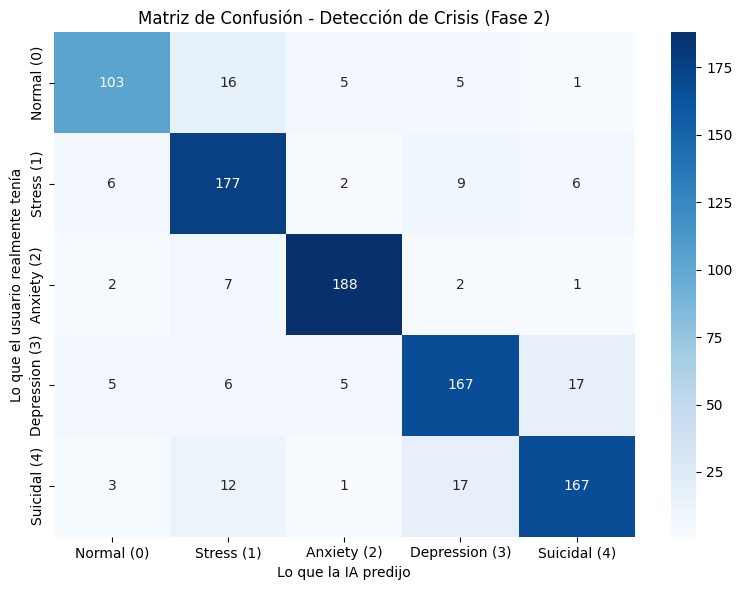

In [ ]:


print("1. Cargando los vectores balanceados con SMOTE...")
# Cargamos los archivos matemáticos que creó RoBERTuito
X = np.load('SMOTE/X_vectores_smote.npy')
y = np.load('SMOTE/y_etiquetas_smote.npy')

print(f"Datos cargados listos para entrenar: {X.shape[0]} registros de {X.shape[1]} dimensiones.")

print("2. Dividiendo en conjunto de Entrenamiento (80%) y Examen (20%)...")
# Guardamos el 20% de los datos para ver si de verdad aprendió o solo memorizó
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("3. Entrenando el Clasificador Neuronal Ligero...")

# red con dos capas ocultas (256 y 128 neuronas)
modelo_clasificador = MLPClassifier(hidden_layer_sizes=(128, 64), 
                                    activation='relu', 
                                    solver='adam', 
                                    alpha=0.05, # evitar que sea paranoica
                                    batch_size=32,
                                    learning_rate_init=0.001,
                                    max_iter=500, 
                                    early_stopping=True,
                                    validation_fraction=0.15,#se incrementa la validacion para vigilarla mejor
                                    n_iter_no_change=15, #paciencia antes de deternse
                                    random_state=42)

# la red pequeña aprende a conectar los 768 números con las 5 etiquetas
modelo_clasificador.fit(X_train, y_train)
print("¡Entrenamiento finalizado en tiempo récord!")

print("4. Evaluando el rendimiento (Sacando el F1-Score y Recall)...")
y_pred = modelo_clasificador.predict(X_test)

nombres_clases = ['Normal (0)', 'Stress (1)', 'Anxiety (2)', 'Depression (3)', 'Suicidal (4)']

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=nombres_clases))

print("5. Guardando el cerebro final para la Fase 3...")
joblib.dump(modelo_clasificador, 'modelos/modelo_MPL_afecto.pkl')
print("Ha sido guardado como 'modelo_MPL_afecto.pkl'")

# --- GENERACIÓN DE LA MATRIZ DE CONFUSIÓN ---
print("Generando imagen de la Matriz de Confusión...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.title('Matriz de Confusión - Detección de Crisis (Fase 2)')
plt.ylabel('Lo que el usuario realmente tenía')
plt.xlabel('Lo que la IA predijo')
plt.tight_layout()
plt.savefig('img/matriz_confusion_fase2.png', dpi=300)
print("Imagen guardada como 'matriz_confusion_fase2.png'. Revisa tu carpeta.")
